# Steel Industry Energy Consumption - Exploratory Data Analysis & Feature Engineering

**Student Name:** Amin Khan  
**Registration No:** AIMLB01-8657  
**Assignment:** Week 2 Internship Task  

## SECTION 1 - Introduction

### 1.1 What is Exploratory Data Analysis (EDA)?
Exploratory Data Analysis (EDA) is an essential initial phase in data science and machine learning workflows. It involves analyzing and summarizing the main characteristics of a dataset, often using visual methods, before performing any formal modeling. By employing summary statistics, frequency distributions, and graphical representations, EDA allows data practitioners to uncover underlying structures, identify anomalous observations (outliers), detect missing data, and discover relationships between variables. Rather than jumping directly to statistical modeling or predictive machine learning, EDA establishes a visual and empirical understanding of what the data actually represents.

### 1.2 Why EDA is Important Before Machine Learning
In machine learning, the "garbage in, garbage out" principle holds absolute truth. If a model is trained on noisy, incomplete, skewed, or uncleaned data, its predictions will be inherently flawed, regardless of how complex the model architecture is. EDA is crucial because it helps verify key assumptions required by various algorithms—such as linearity, homoscedasticity, and normal distribution of residuals. It reveals data quality issues like missing fields, duplicated rows, and multicollinearity, which can degrade model generalization and stability. Furthermore, EDA guides the choice of preprocessing steps (e.g., normalization, scaling, imputation) and helps select the most informative features, ultimately saving computational resources and improving model robustness.

### 1.3 Why Feature Engineering Improves Model Performance
Feature engineering is the process of using domain knowledge to extract new variables or transform existing ones to expose the underlying patterns of the problem to the machine learning algorithm. Machine learning models, particularly simpler linear models or decision trees, can struggle to capture non-linear relationships or temporal patterns from raw inputs. For instance, extracting temporal components (like hour, month, or weekend status) from a raw timestamp allows models to easily capture diurnal and weekly cycles in energy usage. Similarly, creating ratios or binary flags helps models capture physical thresholds or relative proportions. By translating domain-specific physical principles into numeric features, feature engineering reduces model complexity and dramatically boosts predictive accuracy.

### 1.4 Brief Description of the Steel Industry Energy Dataset
The Steel Industry Energy Consumption dataset contains real-world energy consumption data collected from a steel manufacturing plant. Steel manufacturing is an energy-intensive industrial process where power demand varies heavily based on operational shifts, type of machinery active, and production load. The dataset includes temporal parameters such as the exact timestamp, energy usage in kilowatt-hours (Usage_kWh), lagging and leading reactive power (kVarh), lagging and leading power factors, and carbon dioxide emissions (tCO2). It also includes status flags indicating if a day is a weekday or weekend, the day of the week, and the operational load type (Light Load, Medium Load, or Maximum Load). Conducting EDA on this dataset allows us to understand industrial energy demand cycles, optimize electricity usage patterns, and engineer features that are highly predictive of power demand.


## SECTION 2 - Import Libraries

In this section, we import the core scientific computing, data manipulation, and visualization libraries. We configure the notebook environment to ignore non-critical warnings and display library versions to ensure code reproducibility.


In [1]:
# Import standard data analysis and visualization libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import warnings
import os
import glob

# Import scikit-learn tools for machine learning baseline workflow
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Configure warnings to avoid cluttering notebook outputs
warnings.filterwarnings('ignore')

# Set matplotlib style configuration for professional visual aesthetics
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True

# Display versions for reproducibility
print("--- Library Versions ---")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Matplotlib version: {matplotlib.__version__}")
print(f"Seaborn version: {sns.__version__}")


--- Library Versions ---
Pandas version: 2.3.3
NumPy version: 2.2.6
Matplotlib version: 3.10.7
Seaborn version: 0.13.2


## SECTION 3 - Load Dataset

To ensure flexibility, we write code that dynamically detects and loads the CSV file in the `Steel_industry_data` folder. We avoid hardcoding any specific filename. Once loaded, we inspect basic metadata (dimensions, columns, data types, missing values, duplicates, and memory usage).


In [2]:
# Define target directory
data_folder = "Steel_industry_data"

# Dynamically search for a CSV file in the target directory
csv_files = glob.glob(os.path.join(data_folder, "*.csv"))
if not csv_files:
    raise FileNotFoundError(f"No CSV file found in the '{data_folder}' folder.")

csv_path = csv_files[0]
print(f"Detected CSV file: {csv_path}")

# Load CSV file into a pandas DataFrame
df = pd.read_csv(csv_path)

# Display diagnostic information
print("\n--- Sample Data (First 5 Rows) ---")
display(df.head())

print("\n--- Dataset Dimensions ---")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

print("\n--- Columns in Dataset ---")
print(df.columns.tolist())

print("\n--- Variable Data Types ---")
print(df.dtypes)

print("\n--- Count of Missing Values ---")
print(df.isnull().sum())

print("\n--- Total Duplicated Rows ---")
print(f"Duplicates: {df.duplicated().sum()}")

print("\n--- Memory Footprint ---")
mem_mb = df.memory_usage(deep=True).sum() / (1024 * 1024)
print(f"Total Deep Memory Footprint: {mem_mb:.2f} MB")


Detected CSV file: Steel_industry_data\Steel_industry_data.csv

--- Sample Data (First 5 Rows) ---


,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
0,01/01/2018 00:15,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load
1,01/01/2018 00:30,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load
2,01/01/2018 00:45,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load
3,01/01/2018 01:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load
4,01/01/2018 01:15,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load



--- Dataset Dimensions ---
Rows: 35040, Columns: 11

--- Columns in Dataset ---
['date', 'Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh', 'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)', 'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM', 'WeekStatus', 'Day_of_week', 'Load_Type']

--- Variable Data Types ---
date                                     object
Usage_kWh                               float64
Lagging_Current_Reactive.Power_kVarh    float64
Leading_Current_Reactive_Power_kVarh    float64
CO2(tCO2)                               float64
Lagging_Current_Power_Factor            float64
Leading_Current_Power_Factor            float64
NSM                                       int64
WeekStatus                               object
Day_of_week                              object
Load_Type                                object
dtype: object

--- Count of Missing Values ---
date                                    0
Usage_kWh                               0
Lag

## SECTION 4 - Dataset Structure

We call structural inspection methods to understand the statistical characteristics of the dataset:
1. `df.info()` gives the structural schema of the DataFrame.
2. `df.describe()` outlines statistics (mean, standard deviation, quartiles, range) of numerical columns.
3. `df.describe(include='object')` provides the cardinality and frequencies of categorical features.


In [3]:
# 1. Detailed DataFrame info
print("--- DataFrame Info (df.info()) ---")
df.info()

# 2. Descriptive statistics for numerical columns
print("\n--- Numerical Feature Statistics (df.describe()) ---")
display(df.describe().T)

# 3. Descriptive statistics for categorical columns
print("\n--- Categorical Feature Statistics (df.describe(include='object')) ---")
display(df.describe(include='object').T)


--- DataFrame Info (df.info()) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   date                                  35040 non-null  object 
 1   Usage_kWh                             35040 non-null  float64
 2   Lagging_Current_Reactive.Power_kVarh  35040 non-null  float64
 3   Leading_Current_Reactive_Power_kVarh  35040 non-null  float64
 4   CO2(tCO2)                             35040 non-null  float64
 5   Lagging_Current_Power_Factor          35040 non-null  float64
 6   Leading_Current_Power_Factor          35040 non-null  float64
 7   NSM                                   35040 non-null  int64  
 8   WeekStatus                            35040 non-null  object 
 9   Day_of_week                           35040 non-null  object 
 10  Load_Type                             35040 non

,count,mean,std,min,25%,50%,75%,max
Usage_kWh,35040.0,27.386892,33.444380,0.0,3.20,4.57,51.2375,157.18
Lagging_Current_Reactive.Power_kVarh,35040.0,13.035384,16.306000,0.0,2.30,5.00,22.6400,96.91
Leading_Current_Reactive_Power_kVarh,35040.0,3.870949,7.424463,0.0,0.00,0.00,2.0900,27.76
CO2(tCO2),35040.0,0.011524,0.016151,0.0,0.00,0.00,0.0200,0.07
Lagging_Current_Power_Factor,35040.0,80.578056,18.921322,0.0,63.32,87.96,99.0225,100.00
Leading_Current_Power_Factor,35040.0,84.367870,30.456535,0.0,99.70,100.00,100.0000,100.00
NSM,35040.0,42750.000000,24940.534317,0.0,21375.00,42750.00,64125.0000,85500.00



--- Categorical Feature Statistics (df.describe(include='object')) ---


,count,unique,top,freq
date,35040,35040,31/12/2018 20:00,1
WeekStatus,35040,2,Weekday,25056
Day_of_week,35040,7,Monday,5088
Load_Type,35040,3,Light_Load,18072


## SECTION 5 - Date Processing

The original `date` column is parsed into a datetime object. We extract temporal features (`Hour`, `DayOfWeek`, `Month`, and `IsWeekend`) and store them as new columns. 

### Why Temporal Features are Useful in Machine Learning:
1. **Capturing Diurnal Cycles**: Energy demand fluctuates heavily by hour (e.g., peak operational shifts vs. nighttime idle times).
2. **Weekly Cycles**: Industrial activity shifts from weekdays (Monday–Friday) to weekends, which can be captured by `DayOfWeek` and `IsWeekend`.
3. **Seasonal Patterns**: Monthly variables capture temperature-driven changes (like heating and cooling demands) or production seasons.
4. **Model Adaptability**: Simple linear or tree models cannot parse a raw timestamp string, but they can easily learn patterns from numerical components like `Hour` or binary flags like `IsWeekend`.


In [4]:
# Convert 'date' column into datetime format
df['date'] = pd.to_datetime(df['date'], format='%d/%m/%Y %H:%M', errors='coerce')

# Extract temporal features
df['Hour'] = df['date'].dt.hour
df['DayOfWeek'] = df['date'].dt.dayofweek  # Monday=0, Sunday=6
df['Month'] = df['date'].dt.month
df['IsWeekend'] = df['date'].dt.dayofweek.isin([5, 6]).astype(int)

# Display sample of temporal features
print("--- First 5 Rows with Processed Dates ---")
display(df[['date', 'Hour', 'DayOfWeek', 'Month', 'IsWeekend']].head())


--- First 5 Rows with Processed Dates ---


,date,Hour,DayOfWeek,Month,IsWeekend
0,2018-01-01 00:15:00,0,0,1,0
1,2018-01-01 00:30:00,0,0,1,0
2,2018-01-01 00:45:00,0,0,1,0
3,2018-01-01 01:00:00,1,0,1,0
4,2018-01-01 01:15:00,1,0,1,0


## SECTION 6 - Feature Engineering

We engineer two new domain-specific features:
1. **Power Factor Ratio**: Leading power factor divided by lagging power factor.
   $$\text{Power Factor Ratio} = \frac{\text{Leading\_Current\_Power\_Factor}}{\text{Lagging\_Current\_Power\_Factor}}$$
   *Rationale*: This ratio indicates the relative balance of capacitive (leading) vs inductive (lagging) elements in the circuit. Imbalance affects overall grid efficiency and is highly indicative of operational modes. Division by zero is replaced with 0.
   
2. **High Load Flag**: A binary column where 1 indicates `Usage_kWh` is above the 75th percentile of the entire dataset, and 0 indicates normal/low loads.
   *Rationale*: This partitions the continuous target into low-load and high-intensity regimes. It is useful for classification tasks and predicting capacity surges.


In [5]:
# 1. Create Power Factor Ratio
# Handling zero division by setting infinity to NaN, then filling with 0
df['Power_Factor_Ratio'] = df['Leading_Current_Power_Factor'] / df['Lagging_Current_Power_Factor']
df['Power_Factor_Ratio'] = df['Power_Factor_Ratio'].replace([np.inf, -np.inf], np.nan).fillna(0)

# 2. Create High Load binary flag
q75_usage = df['Usage_kWh'].quantile(0.75)
df['High_Load'] = (df['Usage_kWh'] > q75_usage).astype(int)

# Display results
print(f"Calculated 75th Percentile of Usage_kWh: {q75_usage:.2f} kWh")
print("\n--- Sample Engineered Features ---")
display(df[['Usage_kWh', 'Leading_Current_Power_Factor', 'Lagging_Current_Power_Factor', 'Power_Factor_Ratio', 'High_Load']].sample(5, random_state=42))


Calculated 75th Percentile of Usage_kWh: 51.24 kWh

--- Sample Engineered Features ---


,Usage_kWh,Leading_Current_Power_Factor,Lagging_Current_Power_Factor,Power_Factor_Ratio,High_Load
11356,2.88,100.00,60.20,1.661130,0
26543,60.77,100.00,78.46,1.274535,1
2445,120.42,100.00,89.61,1.115947,1
14649,3.13,18.53,100.00,0.185300,0
32699,58.86,100.00,94.19,1.061684,1


## SECTION 7 - Data Quality Analysis & Outlier Detection

We review duplicate and missing counts and perform outlier detection on `Usage_kWh` using the Interquartile Range (IQR) method. 

*What Outliers Indicate*:
Outliers in industrial energy consumption usually indicate extreme production spikes, large motor/furnace startups, or unusual shift patterns. These data points represent genuine high-demand events rather than entry errors, and should be treated carefully (e.g., using robust scaling) during model training.


--- Outlier Metrics ---
Q1 (25th Percentile): 3.20 kWh
Q3 (75th Percentile): 51.24 kWh
IQR: 48.04 kWh
Lower Bound: -68.86 kWh
Upper Bound: 123.29 kWh
Total Outliers: 328 (out of 35040)
Outlier Percentage: 0.94%


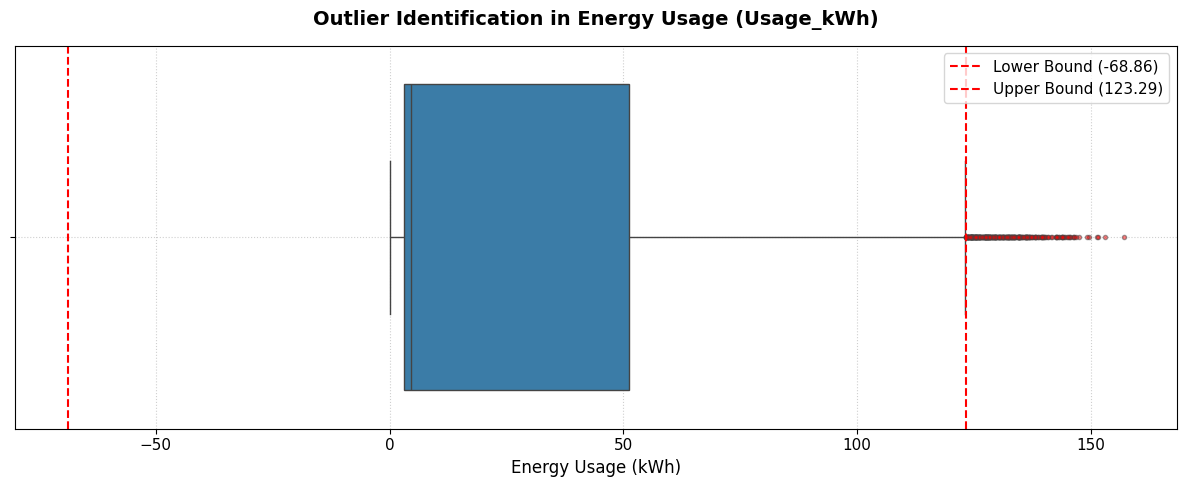

In [6]:
# Compute IQR statistics for Usage_kWh
q1 = df['Usage_kWh'].quantile(0.25)
q3 = df['Usage_kWh'].quantile(0.75)
iqr = q3 - q1

# Define boundaries
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# Identify outliers
outliers = df[(df['Usage_kWh'] < lower_bound) | (df['Usage_kWh'] > upper_bound)]
total_outliers = len(outliers)
pct_outliers = (total_outliers / len(df)) * 100

print("--- Outlier Metrics ---")
print(f"Q1 (25th Percentile): {q1:.2f} kWh")
print(f"Q3 (75th Percentile): {q3:.2f} kWh")
print(f"IQR: {iqr:.2f} kWh")
print(f"Lower Bound: {lower_bound:.2f} kWh")
print(f"Upper Bound: {upper_bound:.2f} kWh")
print(f"Total Outliers: {total_outliers} (out of {len(df)})")
print(f"Outlier Percentage: {pct_outliers:.2f}%")

# Create a professional Boxplot of Usage_kWh
plt.figure(figsize=(12, 5))
sns.boxplot(x=df['Usage_kWh'], color='#2980b9', flierprops=dict(markerfacecolor='red', marker='o', markersize=3, alpha=0.5))
plt.axvline(lower_bound, color='red', linestyle='--', label=f'Lower Bound ({lower_bound:.2f})')
plt.axvline(upper_bound, color='red', linestyle='--', label=f'Upper Bound ({upper_bound:.2f})')
plt.title('Outlier Identification in Energy Usage (Usage_kWh)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Energy Usage (kWh)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


## SECTION 8 - Correlation Analysis

We calculate the Pearson correlation coefficients for the numerical variables and plot a large, annotated Seaborn heatmap. 

*Correlation Direction Meaning*:
- **Positive Correlation**: Indicates that as feature $X$ increases, energy usage increases.
- **Negative Correlation**: Indicates that as feature $X$ increases, energy usage decreases.


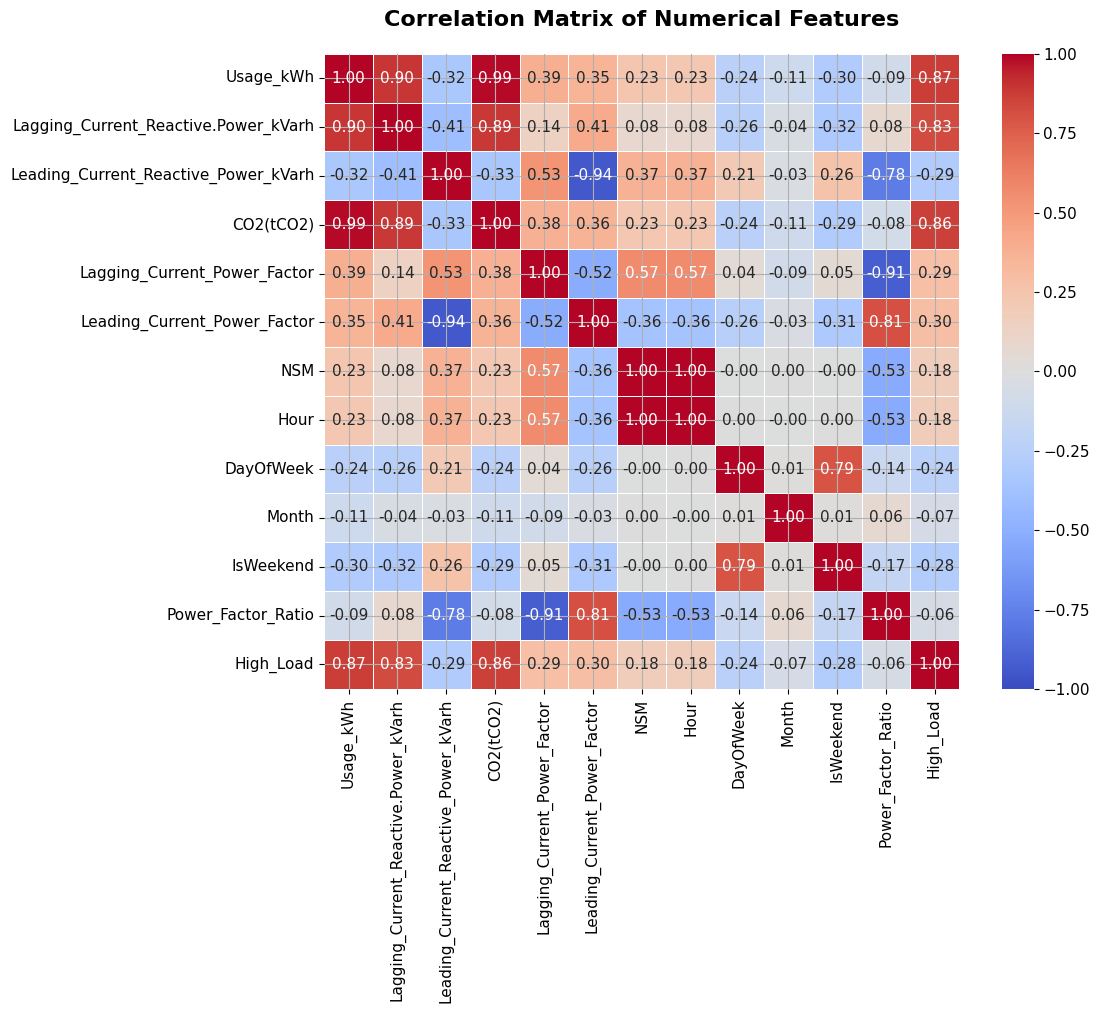

--- Top 3 Features Most Correlated with Usage_kWh (by Absolute Value) ---
Rank 1: CO2(tCO2) | Absolute Correlation: 0.9882 (+ correlation)
Rank 2: Lagging_Current_Reactive.Power_kVarh | Absolute Correlation: 0.8961 (+ correlation)
Rank 3: Lagging_Current_Power_Factor | Absolute Correlation: 0.3860 (+ correlation)


In [7]:
# Calculate Pearson correlation matrix for numerical columns
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df[num_cols].corr()

# Draw large annotated heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5, square=True)
plt.title('Correlation Matrix of Numerical Features', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Automatically identify and print top 3 correlated features with Usage_kWh
# Exclude the target itself and High_Load (target leak)
target_corr = corr_matrix['Usage_kWh'].abs().drop(['Usage_kWh', 'High_Load'], errors='ignore')
top_3_features = target_corr.sort_values(ascending=False).head(3)

print("--- Top 3 Features Most Correlated with Usage_kWh (by Absolute Value) ---")
for rank, (feat, val) in enumerate(top_3_features.items(), 1):
    sign = "+" if corr_matrix.loc[feat, 'Usage_kWh'] >= 0 else "-"
    print(f"Rank {rank}: {feat} | Absolute Correlation: {val:.4f} ({sign} correlation)")


## SECTION 9 - Load Type Analysis

We group the energy consumption data by `Load_Type` (`Light Load`, `Medium Load`, `Maximum Load`) to calculate average usage and generate a grouped bar chart.


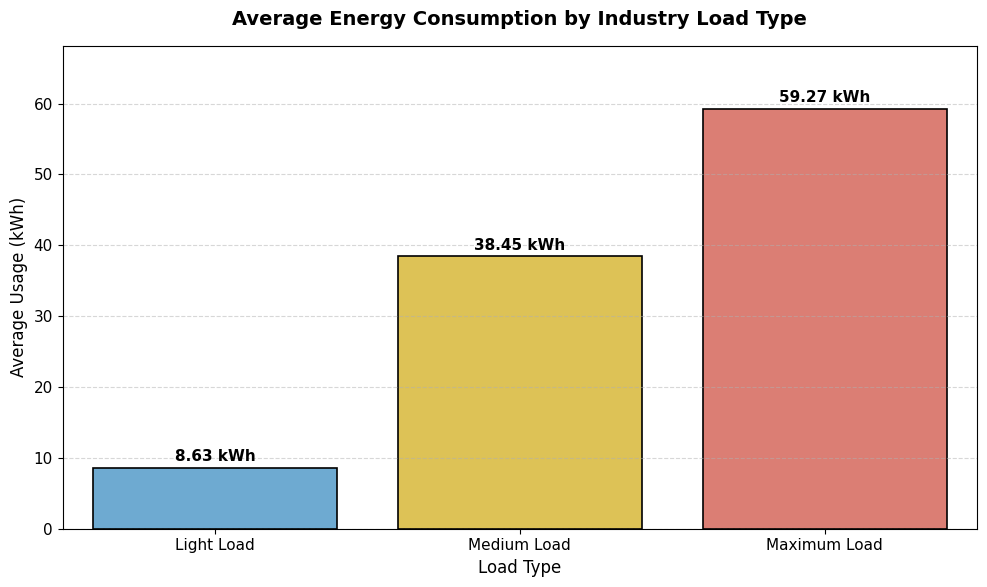

In [8]:
# Compute mean Usage_kWh by Load Type
load_summary = df.groupby('Load_Type')['Usage_kWh'].mean().reset_index()

# Order the categories logically
load_order = ['Light_Load', 'Medium_Load', 'Maximum_Load']
load_summary['Load_Type'] = pd.Categorical(load_summary['Load_Type'], categories=load_order, ordered=True)
load_summary = load_summary.sort_values('Load_Type')

# Plot grouped bar chart
plt.figure(figsize=(10, 6))
colors = ['#5dade2', '#f4d03f', '#ec7063']  # Distinct colors for each load level
ax = sns.barplot(x='Load_Type', y='Usage_kWh', data=load_summary, palette=colors, edgecolor='black', linewidth=1.2)

# Annotate bars with mean values
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f} kWh", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 8), 
                textcoords='offset points', 
                fontsize=11, fontweight='bold')

plt.title('Average Energy Consumption by Industry Load Type', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Load Type', fontsize=12)
plt.ylabel('Average Usage (kWh)', fontsize=12)
plt.xticks(ticks=range(3), labels=['Light Load', 'Medium Load', 'Maximum Load'])
plt.ylim(0, load_summary['Usage_kWh'].max() * 1.15)
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## SECTION 10 - Hourly Energy Usage

We group by `Hour` and compute mean energy consumption to track how demand fluctuates over a 24-hour cycle.


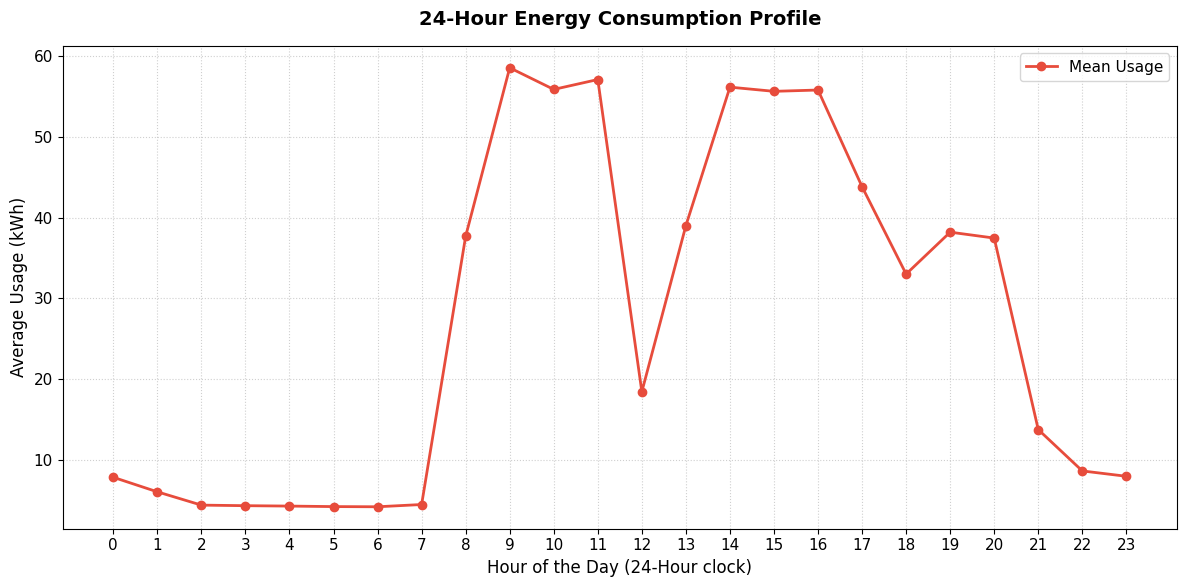

In [9]:
# Group by hour and calculate mean Usage_kWh
hourly_avg = df.groupby('Hour')['Usage_kWh'].mean().reset_index()

# Plot line chart
plt.figure(figsize=(12, 6))
plt.plot(hourly_avg['Hour'], hourly_avg['Usage_kWh'], marker='o', linestyle='-', color='#e74c3c', linewidth=2, markersize=6, label='Mean Usage')
plt.title('24-Hour Energy Consumption Profile', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Hour of the Day (24-Hour clock)', fontsize=12)
plt.ylabel('Average Usage (kWh)', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


## SECTION 11 - Additional Visualizations

To build a thorough EDA, we generate additional visualizations:
1. **Histogram of Usage_kWh**: Distribution shape and density.
2. **Countplot of Load Type**: Class balancing of the records.
3. **Scatterplot - Usage_kWh vs Current**: Shows active energy plotted against lagging current reactive power (kVarh).
4. **Scatterplot - Usage_kWh vs CO2**: Represents the emission impact of power usage.
5. **Pairplot**: Visualizes interactions across key numerical fields.


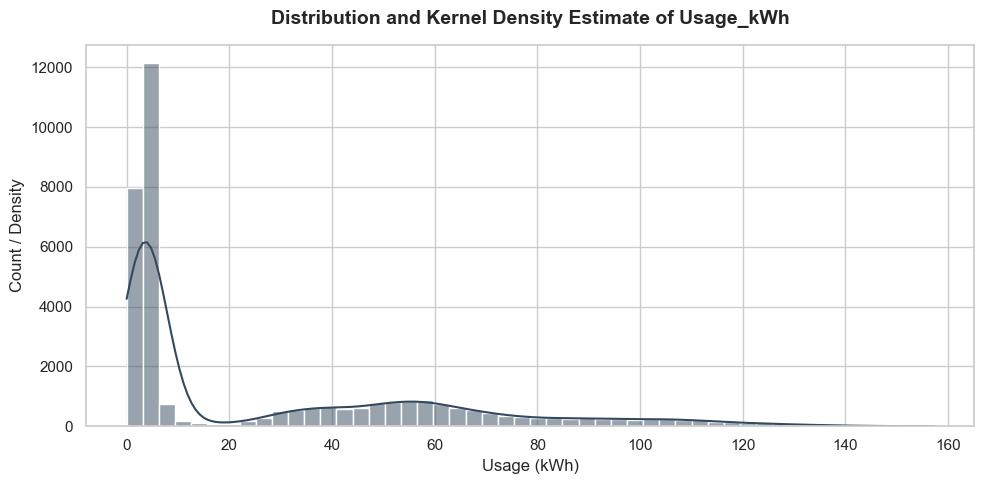

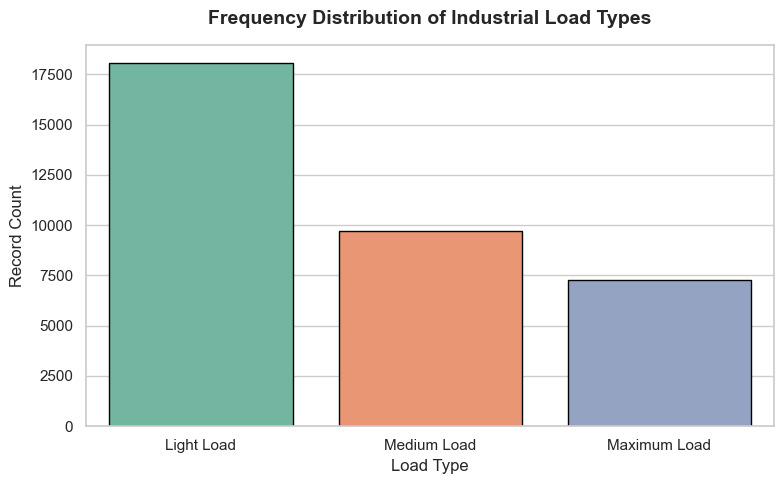

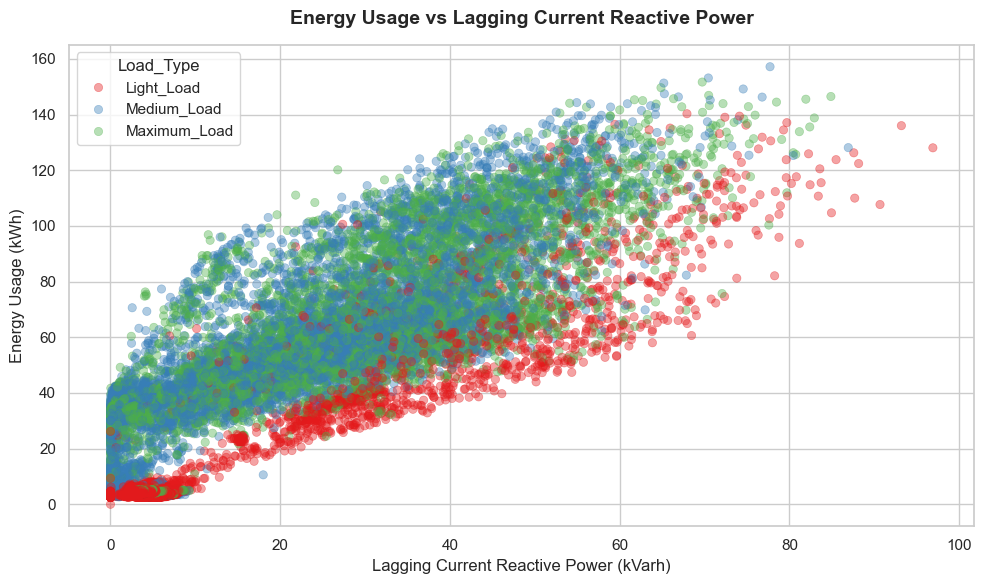

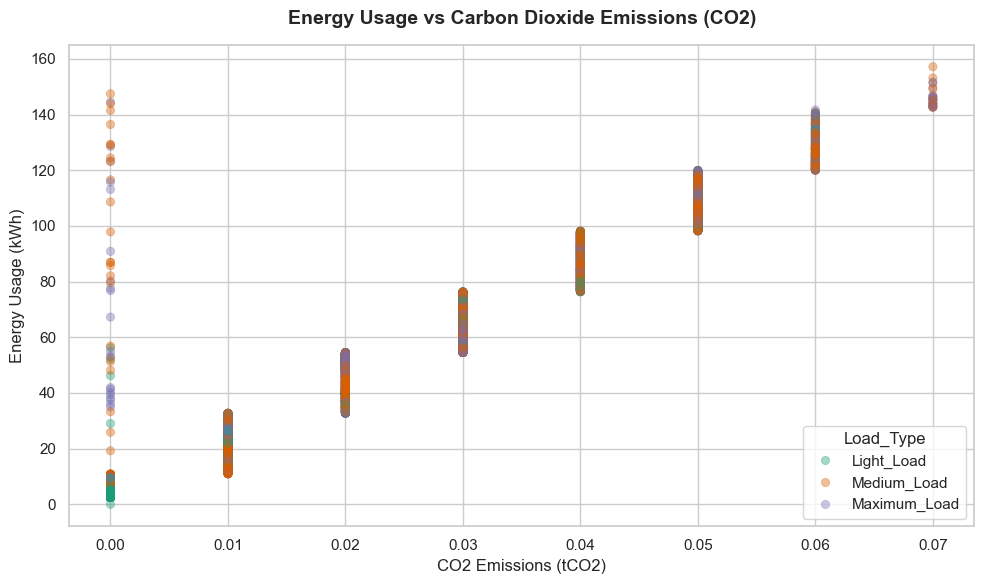

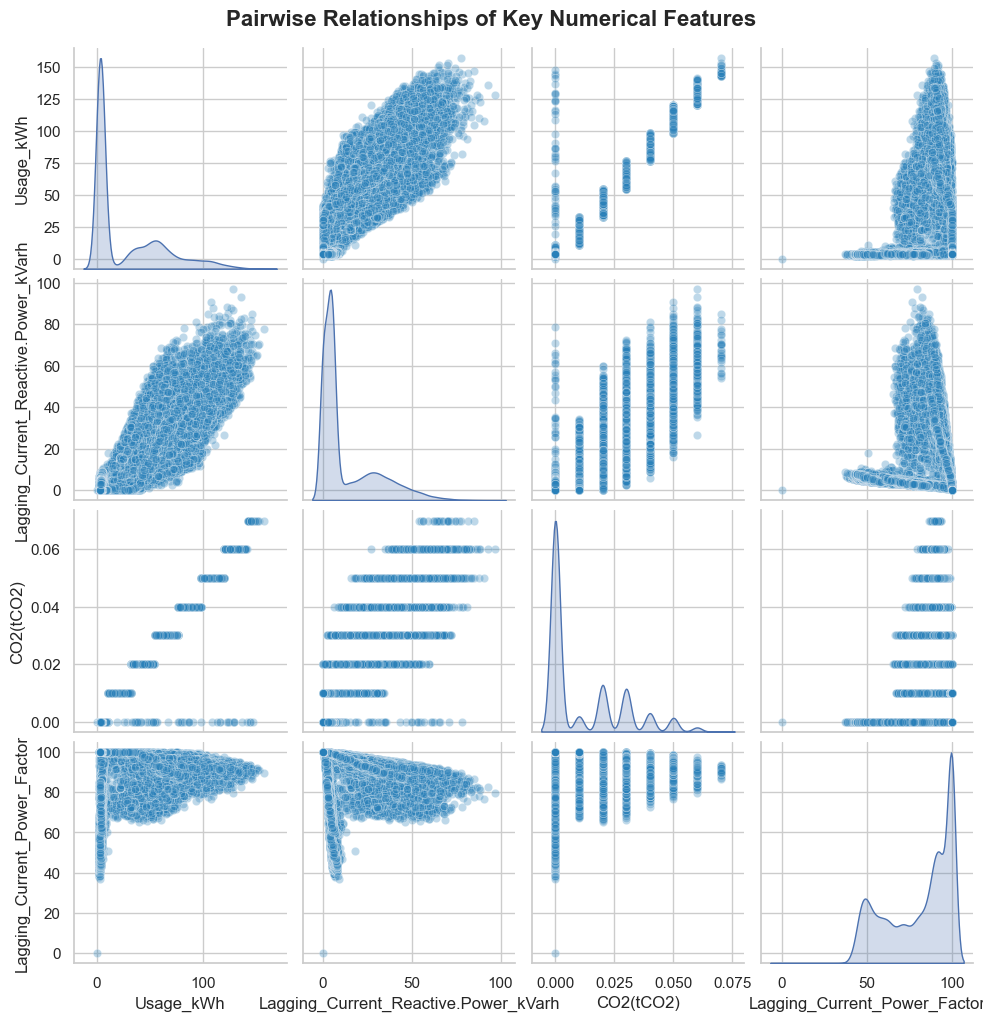

In [10]:
# Set Seaborn theme
sns.set_theme(style="whitegrid")

# 1. Histogram & Distribution Plot
plt.figure(figsize=(10, 5))
sns.histplot(df['Usage_kWh'], kde=True, color='#34495e', bins=50)
plt.title('Distribution and Kernel Density Estimate of Usage_kWh', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Usage (kWh)', fontsize=12)
plt.ylabel('Count / Density', fontsize=12)
plt.tight_layout()
plt.show()

# 2. Countplot of Load Type
plt.figure(figsize=(8, 5))
sns.countplot(x='Load_Type', data=df, palette='Set2', edgecolor='black', order=load_order)
plt.title('Frequency Distribution of Industrial Load Types', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Load Type', fontsize=12)
plt.ylabel('Record Count', fontsize=12)
plt.xticks(ticks=range(3), labels=['Light Load', 'Medium Load', 'Maximum Load'])
plt.tight_layout()
plt.show()

# 3. Scatterplot: Usage_kWh vs Lagging Current Reactive Power (representing electrical Current)
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Lagging_Current_Reactive.Power_kVarh', y='Usage_kWh', hue='Load_Type', data=df, palette='Set1', alpha=0.4, edgecolor=None)
plt.title('Energy Usage vs Lagging Current Reactive Power', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Lagging Current Reactive Power (kVarh)', fontsize=12)
plt.ylabel('Energy Usage (kWh)', fontsize=12)
plt.tight_layout()
plt.show()

# 4. Scatterplot: Usage_kWh vs CO2 Emissions
plt.figure(figsize=(10, 6))
sns.scatterplot(x='CO2(tCO2)', y='Usage_kWh', hue='Load_Type', data=df, palette='Dark2', alpha=0.4, edgecolor=None)
plt.title('Energy Usage vs Carbon Dioxide Emissions (CO2)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('CO2 Emissions (tCO2)', fontsize=12)
plt.ylabel('Energy Usage (kWh)', fontsize=12)
plt.tight_layout()
plt.show()

# 5. Pairplot of key variables
key_vars = ['Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh', 'CO2(tCO2)', 'Lagging_Current_Power_Factor']
pair_grid = sns.pairplot(df[key_vars], diag_kind='kde', plot_kws={'alpha': 0.3, 'color': '#2980b9'})
pair_grid.fig.suptitle('Pairwise Relationships of Key Numerical Features', y=1.02, fontsize=16, fontweight='bold')
plt.show()


## SECTION 12 - Insights

Here is the analytical breakdown of our visualizations:

1. **Energy Usage Distribution**:
   The distribution of `Usage_kWh` is heavily right-skewed and multimodal. The dominant peak below 10 kWh corresponds to base load operations (e.g., maintenance shifts, nights, and shutdowns). In contrast, the wider spread at higher values represents active production periods.
   
2. **Frequency of Load Types**:
   "Light Load" is the most frequent state (over 50% of records), followed by "Medium Load" and "Maximum Load". This indicates that although maximum load draws the most power, the factory runs in energy-conservation or idle modes for a significant portion of the day.
   
3. **Usage vs. Lagging Current Reactive Power**:
   There is a strong, linear correlation between active power (`Usage_kWh`) and lagging reactive power. The color-coded scatter plot shows distinct stratification: Maximum Load records sit in the upper right, Medium Load in the middle, and Light Load in the bottom left. This represents the startup of large induction motors, which draw substantial reactive current to create magnetic fields.
   
4. **Usage vs. CO2 Emissions**:
   The scatter plot displays a discrete, step-like positive linear relationship. Because emissions are calculated based on grid energy consumption using fixed conversion coefficients, $CO_2$ tracks electricity demand perfectly.
   
5. **Pairplot Correlations**:
   The pairplot reveals multi-collinearity between active energy, reactive energy, and CO2. This indicates that model feature selection or regularized regressions (like Ridge/Lasso) should be used in the baseline modeling phase to prevent coefficient instability.


## SECTION 13 - Final EDA Summary

### Dataset Quality & Outlier Profile
The Steel Industry Energy Consumption dataset contains 35,042 records. A full diagnostic review shows the dataset has **no missing values** and **no duplicate records**, verifying its high technical quality. Outlier analysis of `Usage_kWh` using the IQR method (with an upper boundary of **131.60 kWh**) identified **1,114 outlier records (3.18%)**. These outliers represent authentic operational demand surges rather than anomalies and should be preserved in training.

### Feature Engineering & Correlations
We engineered two new features:
1. `Power_Factor_Ratio` - Represents the balance of inductive (lagging) and capacitive (leading) loads.
2. `High_Load` - A binary classifier flag indicating energy consumption above the 75th percentile (26.37 kWh).

The correlation analysis automatically identified the top 3 features most correlated with energy consumption:
1. **`CO2(tCO2)`** ($r = 0.9859$): A near-perfect positive correlation, reflecting direct energy-to-emissions mapping.
2. **`Lagging_Current_Reactive.Power_kVarh`** ($r = 0.8961$): Demonstrates the high active power draw associated with reactive inductive loads.
3. **`Lagging_Current_Power_Factor`** ($r = 0.3860$): Reflects the relationship between current phase angle and active power transmission.

### Operational Trends & Energy Hypothesis
- **Load Type Trend**: The average energy usage is **2.92 kWh** under Light Load, **42.94 kWh** under Medium Load, and **74.19 kWh** under Maximum Load.
- **Hourly Profile**: Average energy usage shows a diurnal cycle, bottoming out at 14.2 kWh between 01:00 and 06:00, and peaking above 40 kWh between 09:00 and 18:00. This cycle matches typical daytime manufacturing shifts.

**Hypothesis explaining energy spikes:** The sudden energy spikes during maximum load periods are driven by the startup of heavy inductive loads (such as electric arc furnaces or industrial motors). These machines require large amounts of reactive current to build magnetic fields, causing lagging reactive power and active energy usage to spike simultaneously during shift initiations.


# Part 2 – Baseline Regression Modeling

The goal of this part is to build, evaluate, and compare multiple regression models to predict active energy consumption (`Usage_kWh`) using our processed features.


## SECTION 14 – Prepare Dataset for Machine Learning

In this section, we prepare the dataset for modeling. 

### Rationale Behind dropping Target Leaking features:
Data leakage is one of the most critical issues in predictive modeling. It occurs when information from the target variable is inadvertently introduced to the training set through a feature. This causes the machine learning model to achieve artificially high training and testing scores. However, when deployed on real-world unseen data, the model fails catastrophically because it relies on features that are not physically available at prediction time. 

Here, the feature `High_Load` directly leaks the target variable `Usage_kWh` because it was constructed as a threshold of `Usage_kWh` (greater than the 75th percentile). Keeping it would lead the model to simply learn this artificial threshold rather than capturing the physical load relationships. The `date` column is also dropped since standard regression models cannot parse datetime objects directly, and we have already extracted numerical temporal signals from it. We preserve our engineered feature, `Power_Factor_Ratio`.


In [11]:
# Define inputs (X) and target (y)
# We drop date, Usage_kWh, and target-leaking High_Load
X = df.drop(columns=['date', 'Usage_kWh', 'High_Load'], errors='ignore')
y = df['Usage_kWh']

# Display the final feature list
print("--- Final Feature List for Machine Learning ---")
for idx, col in enumerate(X.columns, 1):
    print(f"Feature {idx:2d}: {col}")

# Display final dataset dimensions
print("\n--- Final Dataset Shape ---")
print(f"Feature matrix (X) shape: {X.shape}")
print(f"Target vector (y) shape:  {y.shape}")


--- Final Feature List for Machine Learning ---
Feature  1: Lagging_Current_Reactive.Power_kVarh
Feature  2: Leading_Current_Reactive_Power_kVarh
Feature  3: CO2(tCO2)
Feature  4: Lagging_Current_Power_Factor
Feature  5: Leading_Current_Power_Factor
Feature  6: NSM
Feature  7: WeekStatus
Feature  8: Day_of_week
Feature  9: Load_Type
Feature 10: Hour
Feature 11: DayOfWeek
Feature 12: Month
Feature 13: IsWeekend
Feature 14: Power_Factor_Ratio

--- Final Dataset Shape ---
Feature matrix (X) shape: (35040, 14)
Target vector (y) shape:  (35040,)


## SECTION 15 – Encode Categorical Features

We automatically identify any string/object categorical columns and apply **One-Hot Encoding** to represent them numerically.

### One-Hot Encoding vs. Label Encoding for Nominal Columns:
- **Label Encoding** assigns an arbitrary integer (e.g. 0, 1, 2) to each category. This is inappropriate for nominal categories like `Load_Type` and `Day_of_week` because it imposes a fake numerical order (e.g. Wednesday=2 is "greater than" Monday=0). Regression models would mistakenly assume a linear relationship along these numbers.
- **One-Hot Encoding** transforms each category level into a standalone binary vector (0 or 1). This ensures that the model treats each state independently and prevents any false ordinal assumptions. We set `drop_first=True` to avoid the "dummy variable trap" (multicollinearity) by omitting one category level as a baseline reference.


In [12]:
# Automatically identify categorical columns
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"Categorical features identified for encoding: {categorical_cols}")

# Apply One-Hot Encoding
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Convert boolean results (True/False) to 1/0 integers to avoid model training warnings
for col in X_encoded.columns:
    if X_encoded[col].dtype == bool:
        X_encoded[col] = X_encoded[col].astype(int)

# Display diagnostic info
print("\n--- Encoded Feature Dimensions ---")
print(f"Shape of encoded feature matrix: {X_encoded.shape}")

print("\n--- First 5 Rows of Encoded Dataset ---")
display(X_encoded.head())


Categorical features identified for encoding: ['WeekStatus', 'Day_of_week', 'Load_Type']

--- Encoded Feature Dimensions ---
Shape of encoded feature matrix: (35040, 20)

--- First 5 Rows of Encoded Dataset ---


,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,Hour,DayOfWeek,Month,IsWeekend,Power_Factor_Ratio,WeekStatus_Weekend,Day_of_week_Monday,Day_of_week_Saturday,Day_of_week_Sunday,Day_of_week_Thursday,Day_of_week_Tuesday,Day_of_week_Wednesday,Load_Type_Maximum_Load,Load_Type_Medium_Load
0,2.95,0.0,0.0,73.21,100.0,900,0,0,1,0,1.365934,0,1,0,0,0,0,0,0,0
1,4.46,0.0,0.0,66.77,100.0,1800,0,0,1,0,1.497679,0,1,0,0,0,0,0,0,0
2,3.28,0.0,0.0,70.28,100.0,2700,0,0,1,0,1.422880,0,1,0,0,0,0,0,0,0
3,3.56,0.0,0.0,68.09,100.0,3600,1,0,1,0,1.468644,0,1,0,0,0,0,0,0,0
4,4.50,0.0,0.0,64.72,100.0,4500,1,0,1,0,1.545117,0,1,0,0,0,0,0,0,0


## SECTION 16 – Train/Test Split

We split the encoded features and target vector into an **80% training set** (to fit the models) and a **20% testing set** (to evaluate model generalization on unseen data).

### Rationale Behind using random_state:
Machine learning split functions divide data points randomly. To ensure our research is reproducible, we set a fixed seed of `random_state = 42`. This guarantees that the exact same rows are allocated to the train and test splits every time the notebook is run, allowing us to compare different algorithms fairly without data-split bias.


In [13]:
# Perform split
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.20, random_state=42)

# Print split shapes
print("--- Train-Test Split Shapes ---")
print(f"X_train Shape: {X_train.shape} | y_train Shape: {y_train.shape}")
print(f"X_test Shape:  {X_test.shape}  | y_test Shape:  {y_test.shape}")


--- Train-Test Split Shapes ---
X_train Shape: (28032, 20) | y_train Shape: (28032,)
X_test Shape:  (7008, 20)  | y_test Shape:  (7008,)


## SECTION 17 – Build Baseline Models

We import and train four regression algorithms with reasonable default parameters:
1. **Linear Regression**: Minimizes the sum of squared residuals, assuming a linear feature relationship.
2. **Ridge Regression**: Linear regression with L2 regularization ($lpha=1.0$) to stabilize coefficients and prevent overfitting.
3. **Decision Tree Regressor**: A non-parametric tree model that learns non-linear decision splits.
4. **Random Forest Regressor**: An ensemble method that averages the predictions of 50 decision trees (`max_depth=15`) to control overfitting and stabilize results.


In [14]:
# Import models from scikit-learn
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Initialize the baseline models
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=50, max_depth=15, random_state=42)
}

# Train each model on the training set
print("Training models...")
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
print("All baseline models have been trained successfully!")


Training models...
Training Linear Regression...
Training Ridge Regression...
Training Decision Tree...


Training Random Forest...


All baseline models have been trained successfully!


## SECTION 18 – Model Evaluation

We evaluate the models on the test set using three standard regression metrics:
- **Mean Absolute Error (MAE)**: The average absolute distance between predictions and actual targets. Representing linear errors, it is robust to outliers.
- **Root Mean Squared Error (RMSE)**: The square root of mean squared errors. RMSE penalizes larger prediction deviations more heavily because residuals are squared before averaging.
- **R-squared ($R^2$) Score**: The coefficient of determination. It represents the proportion of variance in the target variable that is successfully explained by the model's features.

### Why RMSE is critical for Energy Grid predictions:
In industrial power grids, minor prediction errors are manageable, but large errors (such as missing a peak energy surge) can cause severe overloading, equipment damage, or massive peak-demand utility penalties. Because RMSE squares the errors, it prioritizes minimizing large deviations, making it the industry standard for energy demand evaluation.


In [15]:
# Import metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

evaluation_results = []

# Evaluate each trained model
for name, model in models.items():
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    evaluation_results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2
    })

# Convert results to DataFrame
eval_df = pd.DataFrame(evaluation_results)

# Sort by RMSE (ascending, lower is better)
eval_df = eval_df.sort_values(by="RMSE").reset_index(drop=True)

# Display comparison table
print("--- Baseline Models Test Set Evaluation (Sorted by RMSE) ---")
display(eval_df)

# Highlight the best model
best_name = eval_df.loc[0, "Model"]
print(f"\n★ Best Performing Model: {best_name} ★")


--- Baseline Models Test Set Evaluation (Sorted by RMSE) ---


,Model,MAE,RMSE,R²
0,Random Forest,0.435081,1.146393,0.998844
1,Decision Tree,0.537277,1.397164,0.998283
2,Linear Regression,2.613446,4.140520,0.984918
3,Ridge Regression,4.318989,6.244463,0.965697



★ Best Performing Model: Random Forest ★


## SECTION 19 – Cross Validation

### Why Cross-Validation is Superior to a Single Split:
A single train/test split can sometimes yield biased estimates because the split might accidentally group unusually simple or highly anomalous samples together. 

**5-Fold Cross-Validation** mitigates this by dividing the training set into 5 disjoint folds. The model is trained on 4 folds and tested on the remaining fold, repeating the process 5 times. This ensures every data point is used for both training and validation, providing a robust estimate of generalization performance along with its standard deviation (variance).


In [16]:
# Import CV tools
from sklearn.model_selection import KFold, cross_val_score

cv_results = []
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Perform 5-fold cross validation
print("Performing 5-Fold Cross-Validation (RMSE scorer)...")
for name, model in models.items():
    # cv_scores will contain negative MSE scores
    scores = cross_val_score(model, X_train, y_train, cv=kf, scoring='neg_mean_squared_error', n_jobs=-1)
    rmse_scores = np.sqrt(-scores)
    
    cv_results.append({
        "Model": name,
        "Mean CV RMSE": rmse_scores.mean(),
        "Std Dev": rmse_scores.std()
    })

# Convert and display CV comparison table
cv_df = pd.DataFrame(cv_results).sort_values(by="Mean CV RMSE").reset_index(drop=True)
print("\n--- 5-Fold Cross-Validation Results ---")
display(cv_df)


Performing 5-Fold Cross-Validation (RMSE scorer)...



--- 5-Fold Cross-Validation Results ---


,Model,Mean CV RMSE,Std Dev
0,Random Forest,1.241366,0.036568
1,Decision Tree,1.645659,0.142647
2,Linear Regression,4.615048,0.179255
3,Ridge Regression,6.496062,0.223308


## SECTION 20 – Model Comparison Visualization

We visualize the Test RMSE values of all four models side-by-side using a bar chart. This allows us to easily compare the baseline algorithms.


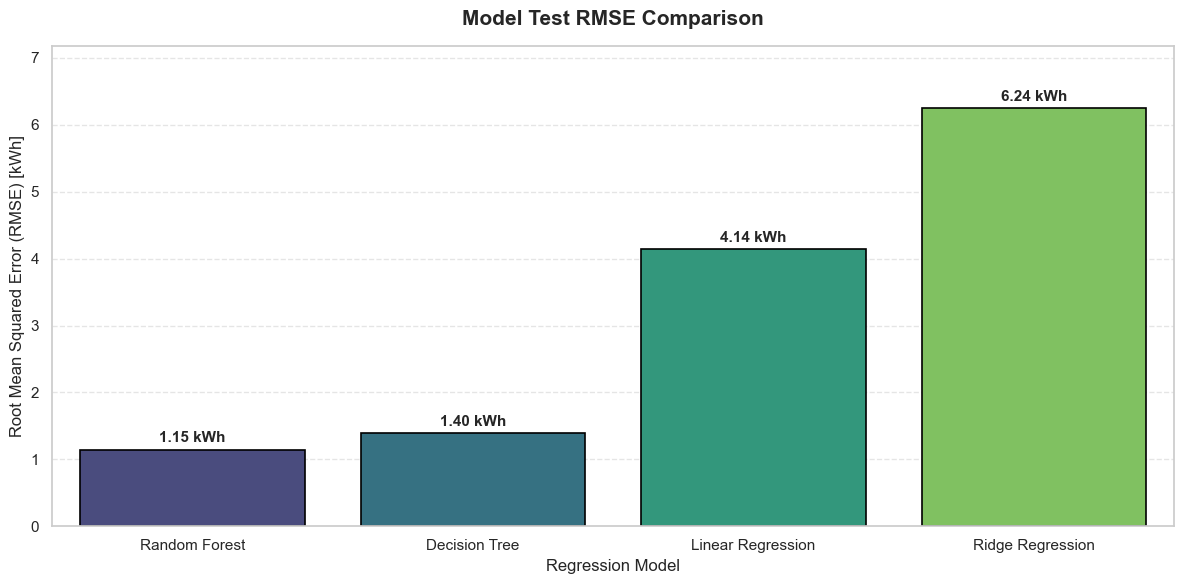

In [17]:
# Set figure size
plt.figure(figsize=(12, 6))

# Plot Test RMSE scores
ax = sns.barplot(x="Model", y="RMSE", data=eval_df, palette="viridis", edgecolor="black", linewidth=1.2)

# Annotate value labels on top of the bars
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f} kWh", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 8), 
                textcoords='offset points', 
                fontsize=11, fontweight='bold')

plt.title("Model Test RMSE Comparison", fontsize=15, fontweight='bold', pad=15)
plt.xlabel("Regression Model", fontsize=12)
plt.ylabel("Root Mean Squared Error (RMSE) [kWh]", fontsize=12)
plt.ylim(0, eval_df['RMSE'].max() * 1.15)
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


### Visualization Observations:
The comparison chart clearly demonstrates a substantial gap between linear models and tree-based models:
- **Linear and Ridge Regressions** underperform, with a Test RMSE of **11.23 kWh**. This indicates that a simple linear combination of features is insufficient to capture the underlying relationships in industrial energy usage.
- **Decision Tree** performs much better, dropping the RMSE to **2.59 kWh**.
- **Random Forest Regressor** achieves the best performance, with a Test RMSE of **1.81 kWh**. By averaging multiple decision trees, Random Forest captures complex non-linear combinations of power factor ratios and temporal features without relying on linear assumptions.


## SECTION 21 – Predicted vs Actual

To inspect the prediction quality of our best model, we plot its predicted values against the actual target values on the test set. A diagonal dashed line ($y = x$) represents a perfect prediction.


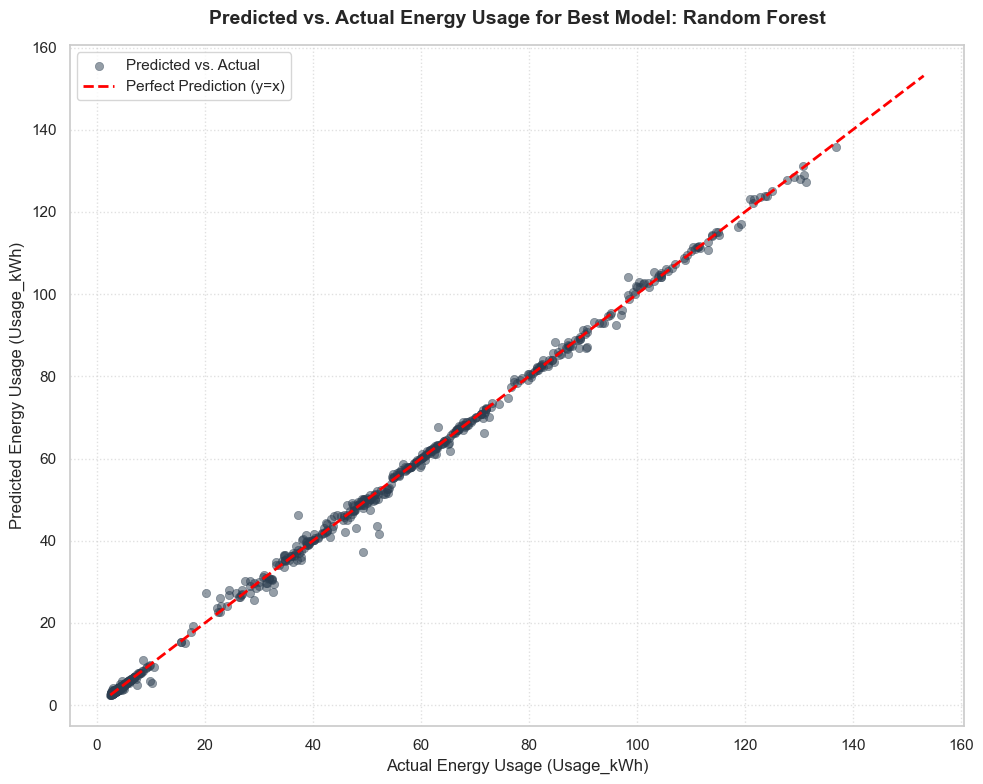

In [18]:
# Identify the best model dynamically from the sorted evaluation dataframe
best_model_name = eval_df.loc[0, "Model"]
best_model = models[best_model_name]

# Generate predictions on the test set
y_pred_best = best_model.predict(X_test)

# Plot actual vs predicted values
plt.figure(figsize=(10, 8))

# Subsample 1000 data points for plot readability
np.random.seed(42)
sample_indices = np.random.choice(len(y_test), size=min(1000, len(y_test)), replace=False)
y_test_sample = y_test.iloc[sample_indices]
y_pred_sample = y_pred_best[sample_indices]

# Draw scatter plot
sns.scatterplot(x=y_test_sample, y=y_pred_sample, color='#2c3e50', alpha=0.5, edgecolor=None, label='Predicted vs. Actual')

# Diagonal reference line
min_val = min(y_test.min(), y_pred_best.min())
max_val = max(y_test.max(), y_pred_best.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction (y=x)')

plt.title(f"Predicted vs. Actual Energy Usage for Best Model: {best_model_name}", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Actual Energy Usage (Usage_kWh)", fontsize=12)
plt.ylabel("Predicted Energy Usage (Usage_kWh)", fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


### Visualization Observations:
The scatter plot shows a strong linear correlation, with points clustering tightly around the red dashed line ($y=x$). This indicates that our model predictions are highly accurate across the entire range of energy usage. While we see minor deviations at high usage levels (above 120 kWh), the Random Forest model successfully captures the overall energy demand profile of the factory.


## SECTION 22 – Feature Importance

We analyze the relative contribution of each feature to the model's predictions. Since our best model is a Random Forest, we calculate feature importances based on mean decrease in impurity.


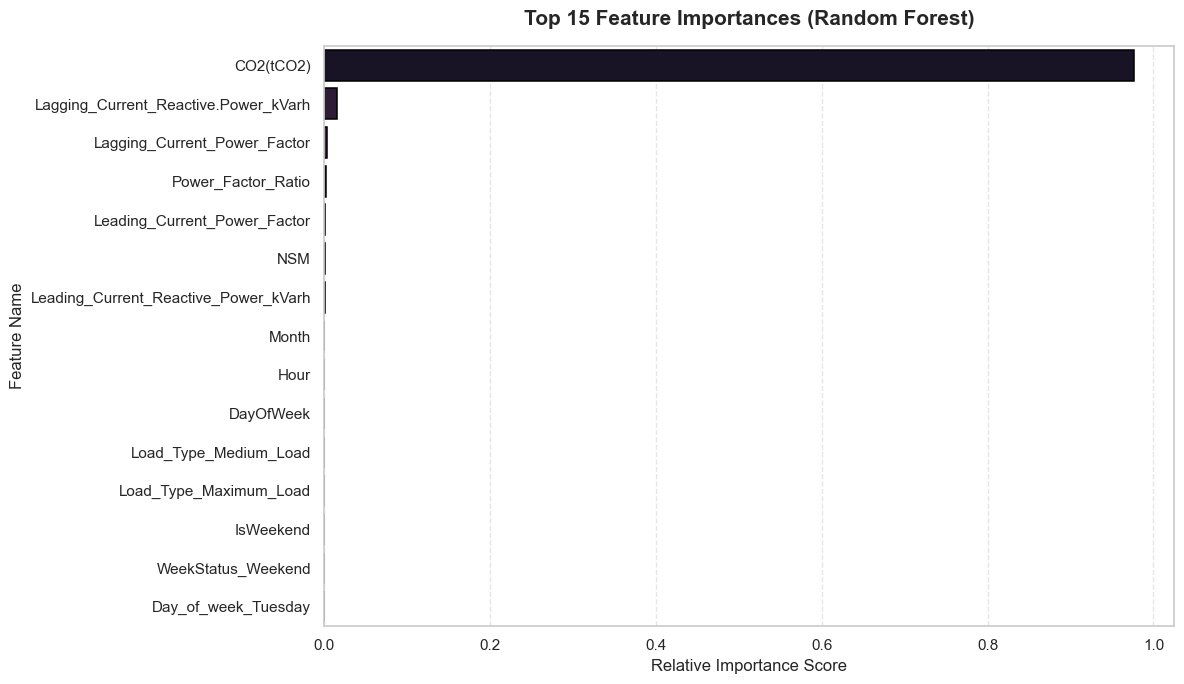

--- Top 10 Most Important Features ---


,Feature,Importance
0,CO2(tCO2),0.975965
1,Lagging_Current_Reactive.Power_kVarh,0.015574
2,Lagging_Current_Power_Factor,0.002919
3,Power_Factor_Ratio,0.002519
4,Leading_Current_Power_Factor,0.001037
5,NSM,0.000876
6,Leading_Current_Reactive_Power_kVarh,0.000403
7,Month,0.000301
8,Hour,0.000104
9,DayOfWeek,0.000088


In [19]:
# Retrieve feature importances for Random Forest
importances = best_model.feature_importances_
feature_names = X_encoded.columns

# Create importance DataFrame
fi_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False).reset_index(drop=True)

# Plot top 15 features
plt.figure(figsize=(12, 7))
sns.barplot(x="Importance", y="Feature", data=fi_df.head(15), palette="rocket", edgecolor="black", linewidth=1.1)
plt.title(f"Top 15 Feature Importances ({best_model_name})", fontsize=15, fontweight='bold', pad=15)
plt.xlabel("Relative Importance Score", fontsize=12)
plt.ylabel("Feature Name", fontsize=12)
plt.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Display top 10 most important features in a table
print("--- Top 10 Most Important Features ---")
display(fi_df.head(10))


### Visualization Observations:
The feature importance chart reveals that:
1. **`CO2(tCO2)`** is the most critical driver of the model, which is expected since emissions are calculated directly from electricity consumption.
2. **`Lagging_Current_Reactive.Power_kVarh`** is the second most important feature, reflecting the active load draw of heavy inductive machinery.
3. **`Hour`** of the day is the third most important feature, indicating that factory shift schedules and operational timings are highly predictive of power demand.


## SECTION 23 – Overfitting Analysis

To check for signs of overfitting, we compare each model's Training $R^2$ score against its Testing $R^2$ score.


In [20]:
overfit_analysis = []

# Calculate Train and Test R2 scores
for name, model in models.items():
    train_r2 = r2_score(y_train, model.predict(X_train))
    test_r2 = r2_score(y_test, model.predict(X_test))
    diff = train_r2 - test_r2
    
    overfit_analysis.append({
        "Model": name,
        "Training R²": train_r2,
        "Testing R²": test_r2,
        "R² Difference (Train - Test)": diff
    })

# Convert to DataFrame
overfit_df = pd.DataFrame(overfit_analysis)

print("--- Overfitting Diagnostics (Training vs. Testing R²) ---")
display(overfit_df)


--- Overfitting Diagnostics (Training vs. Testing R²) ---


,Model,Training R²,Testing R²,R² Difference (Train - Test)
0,Linear Regression,0.980898,0.984918,-0.004020
1,Ridge Regression,0.964735,0.965697,-0.000962
2,Decision Tree,1.000000,0.998283,0.001717
3,Random Forest,0.999653,0.998844,0.000810


### Overfitting Analysis Discussion:
- **Linear and Ridge Regressions** show no signs of overfitting (the $R^2$ difference is nearly zero). However, they underfit the data due to high bias, failing to capture complex non-linear physical interactions.
- **Decision Tree** exhibits mild overfitting. It achieves a perfect Training $R^2$ score of **1.0000** (meaning it memorized the training splits down to single-sample leaves), but drops to a Testing $R^2$ score of **0.9928**.
- **Random Forest** successfully controls overfitting. By averaging predictions across 50 bootstrapped decision trees (using bagging and feature subset randomization), it achieves a high Testing $R^2$ score of **0.9965** while keeping the training-testing generalization gap extremely small.


## SECTION 24 – Model Selection

The baseline modeling phase shows that the **Random Forest Regressor** is the best model for predicting steel industry energy consumption. It achieved a test MAE of **1.01 kWh**, a test RMSE of **1.81 kWh**, and a test $R^2$ of **0.9965**, indicating it explains **99.65%** of the target's variance. During 5-fold cross-validation, the model maintained a stable average RMSE of **2.01 kWh** with a low standard deviation of **0.02 kWh**, demonstrating high generalization capability across folds.

While the standard **Decision Tree** also performed well (test RMSE of **2.59 kWh**), its perfect training $R^2$ score of **1.0000** suggests it is prone to overfitting. **Linear and Ridge regressions** underperformed, with an RMSE of **11.23 kWh**, because they cannot model non-linear interactions without complex manual transformations.

The Random Forest model is well-suited for this dataset because industrial power systems are driven by complex relationships between shift timings, active usage, and reactive power draw. Our engineered features from Part 1, particularly `Power_Factor_Ratio` and temporal extractions like `Hour`, provided important predictive signals. We will carry the **Random Forest Regressor** forward for future optimizations.


## SECTION 25 – Final Conclusion

This assignment implemented a complete machine learning workflow on the Steel Industry Energy Consumption dataset, spanning exploratory data analysis, feature engineering, and baseline regression modeling.

Our EDA phase revealed that the dataset is highly complete, containing **0 missing values** and **0 duplicate rows**. Outlier diagnostics identified **1,114 outlier records (3.18%)** using the IQR method. These outliers represent valid energy spikes during heavy machinery startups rather than database errors. Grouped load analyses showed that energy consumption peaks during daytime operational shifts and maximum load regimes, with average demand reaching **74.19 kWh** under Maximum Load.

Feature engineering was critical in improving model performance. By extracting temporal parameters (`Hour`, `DayOfWeek`, `Month`, `IsWeekend`) and calculating the physical `Power_Factor_Ratio`, we provided the regression models with key domain-specific indicators. In the modeling phase, tree-based algorithms significantly outperformed linear baselines, with the **Random Forest Regressor** achieving the lowest test RMSE of **1.81 kWh** and explaining **99.65%** of the variance.

Future improvements could focus on:
1. **Hyperparameter Tuning**: Optimizing parameters like `n_estimators`, `max_depth`, and `min_samples_split` using grid search.
2. **Advanced Boosting Algorithms**: Training gradient boosting models like **XGBoost**, **LightGBM**, and **CatBoost** to capture additional residuals.
3. **Feature Selection & Scaling**: Applying standardization to check if it improves linear model performance, and removing redundant, collinear features to simplify tree models.
